# **Introduction to NLP -- Assignment**

In [1]:
# install and import important libraries

!pip install contractions

import re, string, unicodedata
import contractions
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Data Loading and Preprocessing**

In [2]:
data = pd.read_csv("/content/Sentiment.csv")
data.head(10)

,id,candidate,candidate_confidence,relevant_yn,relevant_yn_confidence,sentiment,sentiment_confidence,subject_matter,subject_matter_confidence,candidate_gold,...,relevant_yn_gold,retweet_count,sentiment_gold,subject_matter_gold,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
0,1,No candidate mentioned,1.0000,yes,1.0000,Neutral,0.6578,None of the above,1.0000,NaN,...,NaN,5,NaN,NaN,RT @NancyLeeGrahn: How did everyone feel about...,NaN,2015-08-07 09:54:46 -0700,629697200650592256,NaN,Quito
1,2,Scott Walker,1.0000,yes,1.0000,Positive,0.6333,None of the above,1.0000,NaN,...,NaN,26,NaN,NaN,RT @ScottWalker: Didn't catch the full #GOPdeb...,NaN,2015-08-07 09:54:46 -0700,629697199560069120,NaN,NaN
2,3,No candidate mentioned,1.0000,yes,1.0000,Neutral,0.6629,None of the above,0.6629,NaN,...,NaN,27,NaN,NaN,RT @TJMShow: No mention of Tamir Rice and the ...,NaN,2015-08-07 09:54:46 -0700,629697199312482304,NaN,NaN
3,4,No candidate mentioned,1.0000,yes,1.0000,Positive,1.0000,None of the above,0.7039,NaN,...,NaN,138,NaN,NaN,RT @RobGeorge: That Carly Fiorina is trending ...,NaN,2015-08-07 09:54:45 -0700,629697197118861312,Texas,Central Time (US & Canada)
4,5,Donald Trump,1.0000,yes,1.0000,Positive,0.7045,None of the above,1.0000,NaN,...,NaN,156,NaN,NaN,RT @DanScavino: #GOPDebate w/ @realDonaldTrump...,NaN,2015-08-07 09:54:45 -0700,629697196967903232,NaN,Arizona
5,6,Ted Cruz,0.6332,yes,1.0000,Positive,0.6332,None of the above,1.0000,NaN,...,NaN,228,NaN,NaN,"RT @GregAbbott_TX: @TedCruz: ""On my first day ...",NaN,2015-08-07 09:54:44 -0700,629697194283499520,NaN,Central Time (US & Canada)
6,7,No candidate mentioned,1.0000,yes,1.0000,Negative,0.6761,FOX News or Moderators,1.0000,NaN,...,NaN,17,NaN,NaN,RT @warriorwoman91: I liked her and was happy ...,NaN,2015-08-07 09:54:44 -0700,629697192383672320,North Georgia,Eastern Time (US & Canada)
7,8,No candidate mentioned,1.0000,yes,1.0000,Neutral,1.0000,None of the above,1.0000,NaN,...,NaN,0,NaN,NaN,Going on #MSNBC Live with @ThomasARoberts arou...,NaN,2015-08-07 09:54:44 -0700,629697192169750528,New York NY,Eastern Time (US & Canada)
8,9,Ben Carson,1.0000,yes,1.0000,Negative,0.6889,None of the above,0.6444,NaN,...,NaN,0,NaN,NaN,Deer in the headlights RT @lizzwinstead: Ben C...,NaN,2015-08-07 09:54:44 -0700,629697190219243524,NaN,Pacific Time (US & Canada)
9,10,No candidate mentioned,0.4594,yes,0.6778,Negative,0.6778,None of the above,0.4594,NaN,...,NaN,1,NaN,NaN,RT @NancyOsborne180: Last night's debate prove...,NaN,2015-08-07 09:54:42 -0700,629697185093824512,NaN,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13871 entries, 0 to 13870
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         13871 non-null  int64  
 1   candidate                  13775 non-null  object 
 2   candidate_confidence       13871 non-null  float64
 3   relevant_yn                13871 non-null  object 
 4   relevant_yn_confidence     13871 non-null  float64
 5   sentiment                  13871 non-null  object 
 6   sentiment_confidence       13871 non-null  float64
 7   subject_matter             13545 non-null  object 
 8   subject_matter_confidence  13871 non-null  float64
 9   candidate_gold             28 non-null     object 
 10  name                       13871 non-null  object 
 11  relevant_yn_gold           32 non-null     object 
 12  retweet_count              13871 non-null  int64  
 13  sentiment_gold             15 non-null     obj

In [4]:
data = data[['candidate','text','sentiment']]

In [5]:
pd.set_option('display.max_colwidth', None)
data.head(10)

,candidate,text,sentiment
0,No candidate mentioned,RT @NancyLeeGrahn: How did everyone feel about the Climate Change question last night? Exactly. #GOPDebate,Neutral
1,Scott Walker,RT @ScottWalker: Didn't catch the full #GOPdebate last night. Here are some of Scott's best lines in 90 seconds. #Walker16 http://t.co/ZSfF…,Positive
2,No candidate mentioned,RT @TJMShow: No mention of Tamir Rice and the #GOPDebate was held in Cleveland? Wow.,Neutral
3,No candidate mentioned,RT @RobGeorge: That Carly Fiorina is trending -- hours after HER debate -- above any of the men in just-completed #GOPdebate says she's on …,Positive
4,Donald Trump,RT @DanScavino: #GOPDebate w/ @realDonaldTrump delivered the highest ratings in the history of presidential debates. #Trump2016 http://t.co…,Positive
5,Ted Cruz,"RT @GregAbbott_TX: @TedCruz: ""On my first day I will rescind every illegal executive action taken by Barack Obama."" #GOPDebate @FoxNews",Positive
6,No candidate mentioned,RT @warriorwoman91: I liked her and was happy when I heard she was going to be the moderator. Not anymore. #GOPDebate @megynkelly https://…,Negative
7,No candidate mentioned,Going on #MSNBC Live with @ThomasARoberts around 2 PM ET. #GOPDebate,Neutral
8,Ben Carson,"Deer in the headlights RT @lizzwinstead: Ben Carson, may be the only brain surgeon who has performed a lobotomy on himself. #GOPDebate",Negative
9,No candidate mentioned,RT @NancyOsborne180: Last night's debate proved it! #GOPDebate #BATsAsk @BadassTeachersA #TBATs https://t.co/G2gGjY1bJD,Negative


In [6]:
data.tail(10)

,candidate,text,sentiment
13861,Donald Trump,RT @RWSurferGirl: Why should @realDonaldTrump pledge support to the GOP when the establishment sold out to Obama? #GOPDebate #GOPDebates 🇺🇸,Negative
13862,Donald Trump,"RT @RWSurferGirl: Trump has got it right, nobody would talk about immigration, not untill be brought it up. #GOPDebate #GOPDebates",Positive
13863,Mike Huckabee,So trans soldiers can die for you Huckabee but you can't foot the bill to make them fulfilled as human beings? Really? #GOPDebates,Negative
13864,No candidate mentioned,RT @RWSurferGirl: Is it just me or does anyone else want to punch Chris Wallace in the face? #GOPDebate #GOPDebates 🇺🇸,Negative
13865,Jeb Bush,RT @RWSurferGirl: Fox is cherry picking the candidates. Jeb gets the softball questions. 🇺🇸 #GOPDebates #GOPDebates,Negative
13866,No candidate mentioned,RT @cappy_yarbrough: Love to see men who will never be faced with a pregnancy talk about what I can do with my body ❤️❤️❤️❤️ #GOPDebate,Negative
13867,Mike Huckabee,RT @georgehenryw: Who thought Huckabee exceeded their expectations \n\n#gopdebate #imwithhuck #gop #ccot #teaparty #tcot\n@laura4fairtax http…,Positive
13868,Ted Cruz,"RT @Lrihendry: #TedCruz As President, I will always tell the truth, and do what I said I would do. #GOPDebates",Positive
13869,Donald Trump,"RT @JRehling: #GOPDebate Donald Trump says that he doesn't have time for political correctness. How does calling women ""fat pigs"" save him …",Negative
13870,Ted Cruz,RT @Lrihendry: #TedCruz headed into the Presidential Debates. GO TED!! \n\n#GOPDebates http://t.co/8S67pz8a4A,Positive


In [7]:
data.sentiment.unique()

array(['Neutral', 'Positive', 'Negative'], dtype=object)

In [8]:
data.sentiment.value_counts()

,count
sentiment,
Negative,8493
Neutral,3142
Positive,2236


In [9]:
data.sentiment.value_counts(normalize=True)

,proportion
sentiment,
Negative,0.612285
Neutral,0.226516
Positive,0.161200


#### **Data Pre-processing:**

- Remove html tags.
- Replace contractions in string. (e.g. replace I'm --> I am) and so on.\
- Remove numbers.
- Tokenization
- To remove Stopwords.
- Lemmatized data
- We have used NLTK library to tokenize words , remove stopwords and lemmatize the remaining words.

In [10]:
def strip_html(text):
  soup = BeautifulSoup(text, "html.parser")
  return soup.get_text()

data['text'] = data['text'].apply(lambda x: strip_html(x))
data.head()

,candidate,text,sentiment
0,No candidate mentioned,RT @NancyLeeGrahn: How did everyone feel about the Climate Change question last night? Exactly. #GOPDebate,Neutral
1,Scott Walker,RT @ScottWalker: Didn't catch the full #GOPdebate last night. Here are some of Scott's best lines in 90 seconds. #Walker16 http://t.co/ZSfF…,Positive
2,No candidate mentioned,RT @TJMShow: No mention of Tamir Rice and the #GOPDebate was held in Cleveland? Wow.,Neutral
3,No candidate mentioned,RT @RobGeorge: That Carly Fiorina is trending -- hours after HER debate -- above any of the men in just-completed #GOPdebate says she's on …,Positive
4,Donald Trump,RT @DanScavino: #GOPDebate w/ @realDonaldTrump delivered the highest ratings in the history of presidential debates. #Trump2016 http://t.co…,Positive


In [11]:
def replace_contractions(text):
  return contractions.fix(text)

data['text'] = data['text'].apply(lambda x: replace_contractions(x))
data.head()

,candidate,text,sentiment
0,No candidate mentioned,RT @NancyLeeGrahn: How did everyone feel about the Climate Change question last night? Exactly. #GOPDebate,Neutral
1,Scott Walker,RT @ScottWalker: Did not catch the full #GOPdebate last night. Here are some of Scott's best lines in 90 seconds. #Walker16 http://t.co/ZSfF…,Positive
2,No candidate mentioned,RT @TJMShow: No mention of Tamir Rice and the #GOPDebate was held in Cleveland? Wow.,Neutral
3,No candidate mentioned,RT @RobGeorge: That Carly Fiorina is trending -- hours after HER debate -- above any of the men in just-completed #GOPdebate says she is on …,Positive
4,Donald Trump,RT @DanScavino: #GOPDebate w/ @realDonaldTrump delivered the highest ratings in the history of presidential debates. #Trump2016 http://t.co…,Positive


In [12]:
data['text'] = data['text'].apply(lambda x: nltk.word_tokenize(x))
data.head(10)

,candidate,text,sentiment
0,No candidate mentioned,"[RT, @, NancyLeeGrahn, :, How, did, everyone, feel, about, the, Climate, Change, question, last, night, ?, Exactly, ., #, GOPDebate]",Neutral
1,Scott Walker,"[RT, @, ScottWalker, :, Did, not, catch, the, full, #, GOPdebate, last, night, ., Here, are, some, of, Scott, 's, best, lines, in, 90, seconds, ., #, Walker16, http, :, //t.co/ZSfF…]",Positive
2,No candidate mentioned,"[RT, @, TJMShow, :, No, mention, of, Tamir, Rice, and, the, #, GOPDebate, was, held, in, Cleveland, ?, Wow, .]",Neutral
3,No candidate mentioned,"[RT, @, RobGeorge, :, That, Carly, Fiorina, is, trending, --, hours, after, HER, debate, --, above, any, of, the, men, in, just-completed, #, GOPdebate, says, she, is, on, …]",Positive
4,Donald Trump,"[RT, @, DanScavino, :, #, GOPDebate, w/, @, realDonaldTrump, delivered, the, highest, ratings, in, the, history, of, presidential, debates, ., #, Trump2016, http, :, //t.co…]",Positive
5,Ted Cruz,"[RT, @, GregAbbott_TX, :, @, TedCruz, :, ``, On, my, first, day, I, will, rescind, every, illegal, executive, action, taken, by, Barack, Obama, ., '', #, GOPDebate, @, FoxNews]",Positive
6,No candidate mentioned,"[RT, @, warriorwoman91, :, I, liked, her, and, was, happy, when, I, heard, she, was, going, to, be, the, moderator, ., Not, anymore, ., #, GOPDebate, @, megynkelly, https, :, //…]",Negative
7,No candidate mentioned,"[Going, on, #, MSNBC, Live, with, @, ThomasARoberts, around, 2, PM, ET, ., #, GOPDebate]",Neutral
8,Ben Carson,"[Deer, in, the, headlights, RT, @, lizzwinstead, :, Ben, Carson, ,, may, be, the, only, brain, surgeon, who, has, performed, a, lobotomy, on, himself, ., #, GOPDebate]",Negative
9,No candidate mentioned,"[RT, @, NancyOsborne180, :, Last, night, 's, debate, proved, it, !, #, GOPDebate, #, BATsAsk, @, BadassTeachersA, #, TBATs, https, :, //t.co/G2gGjY1bJD]",Negative


In [13]:
data.tail(10)

,candidate,text,sentiment
13861,Donald Trump,"[RT, @, RWSurferGirl, :, Why, should, @, realDonaldTrump, pledge, support, to, the, GOP, when, the, establishment, sold, out, to, Obama, ?, #, GOPDebate, #, GOPDebates, 🇺🇸]",Negative
13862,Donald Trump,"[RT, @, RWSurferGirl, :, Trump, has, got, it, right, ,, nobody, would, talk, about, immigration, ,, not, untill, be, brought, it, up, ., #, GOPDebate, #, GOPDebates]",Positive
13863,Mike Huckabee,"[So, trans, soldiers, can, die, for, you, Huckabee, but, you, can, not, foot, the, bill, to, make, them, fulfilled, as, human, beings, ?, Really, ?, #, GOPDebates]",Negative
13864,No candidate mentioned,"[RT, @, RWSurferGirl, :, Is, it, just, me, or, does, anyone, else, want, to, punch, Chris, Wallace, in, the, face, ?, #, GOPDebate, #, GOPDebates, 🇺🇸]",Negative
13865,Jeb Bush,"[RT, @, RWSurferGirl, :, Fox, is, cherry, picking, the, candidates, ., Jeb, gets, the, softball, questions, ., 🇺🇸, #, GOPDebates, #, GOPDebates]",Negative
13866,No candidate mentioned,"[RT, @, cappy_yarbrough, :, Love, to, see, men, who, will, never, be, faced, with, a, pregnancy, talk, about, what, I, can, do, with, my, body, ❤️❤️❤️❤️, #, GOPDebate]",Negative
13867,Mike Huckabee,"[RT, @, georgehenryw, :, Who, thought, Huckabee, exceeded, their, expectations, #, gopdebate, #, imwithhuck, #, gop, #, ccot, #, teaparty, #, tcot, @, laura4fairtax, http…]",Positive
13868,Ted Cruz,"[RT, @, Lrihendry, :, #, TedCruz, As, President, ,, I, will, always, tell, the, truth, ,, and, do, what, I, said, I, would, do, ., #, GOPDebates]",Positive
13869,Donald Trump,"[RT, @, JRehling, :, #, GOPDebate, Donald, Trump, says, that, he, does, not, have, time, for, political, correctness, ., How, does, calling, women, ``, fat, pigs, '', save, him, …]",Negative
13870,Ted Cruz,"[RT, @, Lrihendry, :, #, TedCruz, headed, into, the, Presidential, Debates, ., GO, TED, !, !, #, GOPDebates, http, :, //t.co/8S67pz8a4A]",Positive


In [14]:
stop_words = stopwords.words('english')
stop_words = list(set(stop_words))
len(stop_words)

179

In [15]:
def to_lowercase(words):
  new_words = []
  for word in words:
    new_word = word.lower()
    new_words.append(new_word)
  return new_words

def remove_puntuations(words):
  new_words =[]
  for word in words:
    new_word = re.sub(r'[^\w\s]', '', word)
    if new_word != '':
      new_words.append(new_word)
  return new_words

def remove_stopwords(words):
  new_words = []
  for word in words:
    if word not in stop_words:
      new_words.append(word)
  return new_words

def lemmatize_list(words):
  lemmatizer = WordNetLemmatizer()
  new_words = []
  for word in words:
    new_words.append(lemmatizer.lemmatize(word))
  return new_words

def remove_rt(words):
  new_words = []
  for word in words:
    if word != 'rt':
      new_words.append(word)
  return new_words

def normalize(words):
  words = to_lowercase(words)
  words = remove_puntuations(words)
  words = remove_stopwords(words)
  words = lemmatize_list(words)
  words = remove_rt(words)
  return words

data['text'] = data['text'].apply(normalize)
data.head(10)

,candidate,text,sentiment
0,No candidate mentioned,"[nancyleegrahn, everyone, feel, climate, change, question, last, night, exactly, gopdebate]",Neutral
1,Scott Walker,"[scottwalker, catch, full, gopdebate, last, night, scott, best, line, 90, second, walker16, http, tcozsff]",Positive
2,No candidate mentioned,"[tjmshow, mention, tamir, rice, gopdebate, held, cleveland, wow]",Neutral
3,No candidate mentioned,"[robgeorge, carly, fiorina, trending, hour, debate, men, justcompleted, gopdebate, say]",Positive
4,Donald Trump,"[danscavino, gopdebate, w, realdonaldtrump, delivered, highest, rating, history, presidential, debate, trump2016, http, tco]",Positive
5,Ted Cruz,"[gregabbott_tx, tedcruz, first, day, rescind, every, illegal, executive, action, taken, barack, obama, gopdebate, foxnews]",Positive
6,No candidate mentioned,"[warriorwoman91, liked, happy, heard, going, moderator, anymore, gopdebate, megynkelly, http]",Negative
7,No candidate mentioned,"[going, msnbc, live, thomasaroberts, around, 2, pm, et, gopdebate]",Neutral
8,Ben Carson,"[deer, headlight, lizzwinstead, ben, carson, may, brain, surgeon, performed, lobotomy, gopdebate]",Negative
9,No candidate mentioned,"[nancyosborne180, last, night, debate, proved, gopdebate, batsask, badassteachersa, tbats, http, tcog2ggjy1bjd]",Negative


In [16]:
data.tail(10)

,candidate,text,sentiment
13861,Donald Trump,"[rwsurfergirl, realdonaldtrump, pledge, support, gop, establishment, sold, obama, gopdebate, gopdebates]",Negative
13862,Donald Trump,"[rwsurfergirl, trump, got, right, nobody, would, talk, immigration, untill, brought, gopdebate, gopdebates]",Positive
13863,Mike Huckabee,"[trans, soldier, die, huckabee, foot, bill, make, fulfilled, human, being, really, gopdebates]",Negative
13864,No candidate mentioned,"[rwsurfergirl, anyone, else, want, punch, chris, wallace, face, gopdebate, gopdebates]",Negative
13865,Jeb Bush,"[rwsurfergirl, fox, cherry, picking, candidate, jeb, get, softball, question, gopdebates, gopdebates]",Negative
13866,No candidate mentioned,"[cappy_yarbrough, love, see, men, never, faced, pregnancy, talk, body, gopdebate]",Negative
13867,Mike Huckabee,"[georgehenryw, thought, huckabee, exceeded, expectation, gopdebate, imwithhuck, gop, ccot, teaparty, tcot, laura4fairtax, http]",Positive
13868,Ted Cruz,"[lrihendry, tedcruz, president, always, tell, truth, said, would, gopdebates]",Positive
13869,Donald Trump,"[jrehling, gopdebate, donald, trump, say, time, political, correctness, calling, woman, fat, pig, save]",Negative
13870,Ted Cruz,"[lrihendry, tedcruz, headed, presidential, debate, go, ted, gopdebates, http, tco8s67pz8a4a]",Positive


In [17]:
# prompt: check min and max lenths of alphabets in given text

text_lengths = [len(text) for text in data['text']]
min_length = min(text_lengths)
max_length = max(text_lengths)

print("Minimum text length:", min_length)
print("Maximum text length:", max_length)

Minimum text length: 2
Maximum text length: 24


## **Text Vectorization**

In [18]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['text'])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
print("Vocabulary size:", vocab_size)


Vocabulary size: 17662


In [19]:
X = tokenizer.texts_to_sequences(data['text'])
X = pad_sequences(X, maxlen=100)
X.shape

(13871, 100)

In [20]:
X

array([[   0,    0,    0, ...,   10,  843,    1],
       [   0,    0,    0, ...,  673,    3, 6992],
       [   0,    0,    0, ..., 1538,  538,  392],
       ...,
       [   0,    0,    0, ...,   43,   16,    2],
       [   0,    0,    0, ...,  479,  530, 1343],
       [   0,    0,    0, ...,    2,    3,  715]], dtype=int32)

In [21]:
y = data['sentiment']
y

,sentiment
0,Neutral
1,Positive
2,Neutral
3,Positive
4,Positive
...,...
13866,Negative
13867,Positive
13868,Positive
13869,Negative


In [22]:
# import to_categorial

from tensorflow.keras.utils import to_categorical

sentiment_mapping = {'Neutral': 0, 'Positive': 1, 'Negative': 2}
y = y.map(sentiment_mapping)

y = to_categorical(y)
y

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

## **Model Building**

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D

embedding_dim = 128

In [29]:
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(SpatialDropout1D(0.1))
model.add(LSTM(units=128, dropout=0.1, recurrent_dropout=0.1))
model.add(Dense(units=3, activation='softmax'))

In [30]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ ?                           │     0 (unbuilt) │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(X, y, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 39s 185ms/step - accuracy: 0.5989 - loss: 0.9214 - val_accuracy: 0.6905 - val_loss: 0.7235
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 32s 186ms/step - accuracy: 0.7559 - loss: 0.6071 - val_accuracy: 0.6959 - val_loss: 0.7351
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 42s 192ms/step - accuracy: 0.8550 - loss: 0.3940 - val_accuracy: 0.6987 - val_loss: 0.8102
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 32s 184ms/step - accuracy: 0.9074 - loss: 0.2538 - val_accuracy: 0.6894 - val_loss: 0.9284
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.9300 - loss: 0.1926 - val_accuracy: 0.6977 - val_loss: 0.8622
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 42s 191ms/step - accuracy: 0.9464 - loss: 0.1511 - val_accuracy: 0.6984 - val_loss: 0.9731
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 41s 191ms/step - accuracy: 0.9534 - loss: 0.1291 - val_accuracy: 0.6995 - val_loss: 0.9957
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.9560 - loss: 0

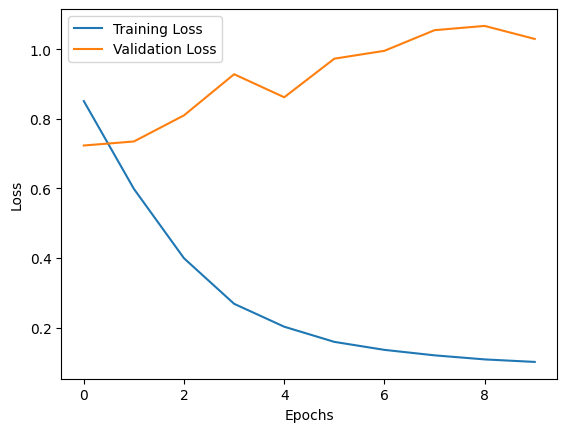

In [33]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

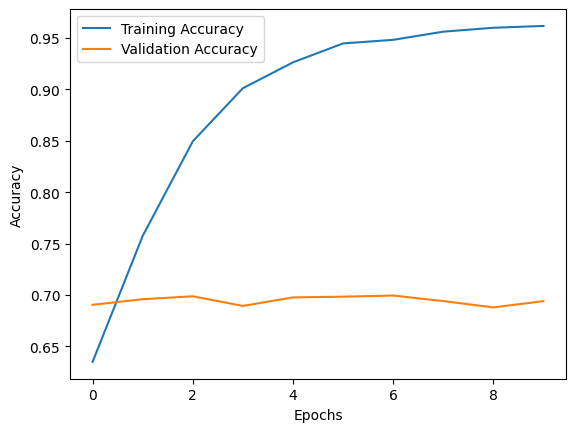

In [35]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()